In [1]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.features import shapes
from scipy import ndimage as ndi
from scipy.ndimage import gaussian_filter
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
import geopandas as gpd
from shapely.geometry import shape
import laspy
import pandas as pd
from scipy.spatial import ConvexHull
from shapely.geometry import Point
import os
import importlib
import logging
from typing import Dict, List, Union
from rasterstats import zonal_stats
import geopandas as gpd
from shapely.geometry import LineString, Point, MultiPolygon, Polygon, MultiPoint

import radial_density

importlib.reload(radial_density)
from radial_density import add_geometry_records,  process_breast_height_geometry
from shapely.ops import unary_union
from scipy.spatial import Delaunay
from shapely import wkt
from shapely.ops import split

### Part One:
### Segmentation for the bamboo plants

#### -------------------------------------------------------------------------
#### STEP 1: Loading the CHM
#### -------------------------------------------------------------------------

In [262]:
inter_dir = '../../02_INTERMEDIATE/PSP-1A-GB-05'
chm_path = f"{inter_dir}/CHM.tif"
chm_smoothed_path = f"{inter_dir}/chm_smoothed.tif" 
clump_line_path = f"{inter_dir}/clump_join.shp"
clump_centers_path = f"../../02_INTERMEDIATE/final_bamboo_parameters_v01.gpkg"
height_measurement_centers = f"../../02_INTERMEDIATE/height_measurement_points.gpkg"
bamboo_polygons_path = f"{inter_dir}/bamboo_segments.gpkg"


height_slice_stack_path = f'{inter_dir}/height_slice_density_stack.tif'
breast_height_density_path = f'{inter_dir}/breast_height_density_m.tif'
slice_heights = [0.3, 0.6, 0.9, 1.2, 1.5, 1.8]

In [263]:
with rasterio.open(chm_smoothed_path) as src:
    chm = src.read(1)
    profile = src.profile
    transform = src.transform

# Replace NoData values or negatives with 0
chm[chm < 0] = 0
chm[np.isnan(chm)] = 0

#### -------------------------------------------------------------------------
#### STEP 2: Thresholding to isolate the vegetation mask
#### -------------------------------------------------------------------------

In [106]:
# Define a minimum height to separate bamboo/canopy from ground
min_height_threshold = 2
# Smooth the CHM heavily *only* for mask creation (keeps true canopy edge tight)
chm_gaussian = gaussian_filter(chm, sigma=1.5) # adjustments alter boundary tightness

# Create your binary mask using the blurred CHM
binary_mask = chm_gaussian > min_height_threshold
# binary_mask = chm > min_height_threshold

#### -------------------------------------------------------------------------
#### STEP 3: Compute the Exact Euclidean Distance Transform (EDT)
#### -------------------------------------------------------------------------

In [107]:
structure_element = np.ones((3, 3), dtype=bool)

# Clean the mask: eliminates isolated stray pixels and narrow protruding shoots
clean_binary_mask = ndi.binary_opening(binary_mask, structure=structure_element)

# Now feed clean_binary_mask into your distance transform instead of binary_mask
distance_map = ndi.distance_transform_edt(clean_binary_mask)

In [77]:
# This calculates the distance from every canopy pixel to the nearest ground pixel.
# Clump centers will have the highest distance values, regardless of height fluctuations.
distance_map = ndi.distance_transform_edt(binary_mask)

#### -------------------------------------------------------------------------
#### STEP 4: Find Local Maxima on the Distance Map
#### -------------------------------------------------------------------------

In [78]:
# 'min_distance' acts as clump radius (in pixels).
# CHM resolution is 0.2m, a min_distance of 5 means clumps must be >= 1m apart.
min_pixel_distance = 5

local_max_coords = peak_local_max(
    distance_map, 
    min_distance=min_pixel_distance, 
    labels=binary_mask
)

# Convert coordinates to a boolean mask
markers_mask = np.zeros(distance_map.shape, dtype=bool)
markers_mask[tuple(local_max_coords.T)] = True

# Label each unique marker point with an integer ID
markers, _ = ndi.label(markers_mask)

#### -------------------------------------------------------------------------
#### STEP 5: Run Marker-Controlled Watershed Segmentation
#### -------------------------------------------------------------------------

In [79]:
# invert the distance map so the clump centers act as deep basins
# and the boundaries act as "ridges".
watershed_mask = distance_map > 1.5 # Skips the outermost 1-2 boundary pixels

labels = watershed(-distance_map, markers, mask=watershed_mask)
# labels = watershed(-distance_map, markers, mask=binary_mask)

#### -------------------------------------------------------------------------
#### STEP 6: Vectorize labeled segments into GeoPandas Polygons
#### -------------------------------------------------------------------------

In [ ]:
# Convert the rasterized segments into vector geometries
polygon_generator = shapes(labels.astype(np.int32), mask=binary_mask, transform=transform)

records = []
for geom, value in polygon_generator:
    if value > 0:  # Ignore background (0)
        records.append({
            'geometry': shape(geom),
            'clump_id': int(value)
        })

# Create a GeoDataFrame with your spatial projection info
gdf = gpd.GeoDataFrame(records, crs=profile['crs'])

#### STEP 7: Clean the bamboo segments using geospatial logic

In [42]:
def clean_bamboo_pipeline(segments_path, centerline_path):
    """
    Automated dMRV cleanup pipeline for linear-planted bamboo plots.
    
    Parameters:
    - segments_path: Path to the raw watershed-exported polygons (GeoJSON/SHP).
    - centerline_path: Path to the LineString vector representing the planting baseline.
    - output_path: Path to save the finalized, audited segments.
    """
    # 1. Load Data (Ensure everything is in a projected CRS like UTM for meter-based math)
    segments = segments_path
    centerline = gpd.read_file(centerline_path).to_crs(segments.crs)
    
    # Safety Check: Ensure matching Coordinate Reference Systems
    if segments.crs != centerline.crs:
        segments = segments.to_crs(centerline.crs)
        
    # Extract the actual LineString geometry
    line_geom = centerline.geometry.iloc[0]
    
    # 2. Corridor Filter: Buffer the centerline by 5 meters
    corridor_mask = line_geom.buffer(5.0)
    
    # Clip the segments to only include geometries inside the 5m corridor
    # (Using intersection ensures parts bleeding past 5m are cleanly sheared off)
    clipped_segments = segments.copy()
    clipped_segments.geometry = segments.geometry.intersection(corridor_mask)
    
    # Remove any empty geometries caused by the clip
    clipped_segments = clipped_segments[~clipped_segments.is_empty]
    
    # 3. Size-Adaptive Morphological Opening (Clean boundaries without losing small clumps)
    def adaptive_buffer(row):
        poly = row.geometry
        area = poly.area
        
        # Define trimming aggressiveness based on pre-clip polygon footprint
        if area < 5.0:
            distance = 0.2   # Gentle 20cm trim for small cohorts
        elif area < 15.0:
            distance = 0.4   # Medium 40cm trim
        else:
            distance = 0.6   # Full 60cm trim for heavy-bleeding giants
            
        # Apply the negative buffer (Erosion)
        eroded = poly.buffer(-distance)
        
        # Safety net: If erosion completely erases a true small clump, fallback to a 10cm trim
        if eroded.is_empty:
            eroded = poly.buffer(-0.1)
            distance = 0.1
            
        # Apply the positive buffer (Dilation) back out to restore scale
        opened = eroded.buffer(distance)
        return opened

    # Execute the adaptive boundary cleaning
    clipped_segments.geometry = clipped_segments.apply(adaptive_buffer, axis=1)
    clipped_segments = clipped_segments[~clipped_segments.is_empty]
    
    # 4. Strict Physical Intersect: Delete polygons NOT touching the actual straight line
    # This strips away random weeds or rocks that sit in the corridor but are off-center
    final_bamboo = clipped_segments[clipped_segments.geometry.intersects(line_geom)]
    
    # 5. Export finalized dMRV layers
    print(f"Pipeline complete! Retained {len(final_bamboo)} true bamboo clumps out of noise.")
    
    return final_bamboo

In [43]:
def adaptive_balloon_popper(gdf):
    """
    Cleans erratic teardrop/ballooning segments by scaling the 
    morphological opening relative to each clump's unique size.
    """
    def clean_single_clump(row):
        poly = row.geometry
        
        # 1. Calculate the True Core Radius using Inscribed Geometry Approximation
        # (Distance from centroid to the closest edge gives us the safe internal radius)
        centroid = poly.centroid
        exterior_coords = list(poly.exterior.coords)
        distances_to_edge = [centroid.distance(Point(v)) for v in exterior_coords]
        
        min_radius = np.min(distances_to_edge)      # Deepest interior core radius
        median_radius = np.median(distances_to_edge)  # Average biological radius
        
        # 2. Check for Ballooning Behavior (The Escape Filter)
        # We check the aspect ratio of the clump's minimum bounding box.
        # A normal clump is close to 1.0. A ballooning teardrop stretches past 1.5.
        rect = poly.minimum_rotated_rectangle
        rect_coords = list(rect.exterior.coords)
        side_1 = Point(rect_coords[0]).distance(Point(rect_coords[1]))
        side_2 = Point(rect_coords[1]).distance(Point(rect_coords[2]))
        aspect_ratio = max(side_1, side_2) / min(side_1, side_2)
        
        # 3. Apply Size-Relative Trimming
        # If it's a severely ballooned shape or an elongated teardrop:
        if aspect_ratio > 1.4:
            # Create a clean circular shield based on the median biological core.
            # This completely shears off the erratic watery tail regardless of shape.
            # We multiply by 1.3 to allow for normal natural canopy asymmetry.
            circular_shield = centroid.buffer(median_radius * 1.3)
            poly = poly.intersection(circular_shield)
        
        # 4. Relative Morphological Opening (Safe for all sizes)
        # We strictly set the erosion distance to 40% of the minimum core radius.
        # This mathematically guarantees the polygon can NEVER become null.
        adaptive_distance = min_radius * 0.40
        
        # Execute the opening
        eroded = poly.buffer(-adaptive_distance)
        opened = eroded.buffer(adaptive_distance)
        
        # Double-safe fallback mechanism
        if opened.is_empty or opened.area < 0.1:
            return poly  # Keep original if math breaks on an extreme shape
            
        return opened

    # Run the adaptive logic across the layer
    cleaned_gdf = gdf.copy()
    cleaned_gdf.geometry = gdf.apply(clean_single_clump, axis=1)
    
    # Remove any broken remnants
    return cleaned_gdf[~cleaned_gdf.is_empty]

In [44]:
def split_polygons_by_true_centers(segments_gdf, centers_path):
    """
    Audits bamboo segments against true field center points.
    If a polygon contains multiple centers, it forces a strict geometric split.
    """
    # 1. Load the true clump centers
    centers_gdf = gpd.read_file(centers_path)
    centers_gdf = centers_gdf[centers_gdf['year'] == 2026]
    
    # Ensure matching coordinate systems
    if segments_gdf.crs != centers_gdf.crs:
        centers_gdf = centers_gdf.to_crs(segments_gdf.crs)
        
    # Reset index to ensure clean tracking
    segments_gdf = segments_gdf.copy().reset_index(drop=True)
    segments_gdf['poly_id'] = segments_gdf.index
    
    # 2. Count how many true points fall inside each segment polygon
    # This acts as our spatial auditor
    pts_in_poly = gpd.sjoin(centers_gdf, segments_gdf, predicate='within')
    
    final_rows = []
    
    # 3. Loop through every polygon to evaluate its point payload
    for poly_id, group in pts_in_poly.groupby('poly_id'):
        original_row = segments_gdf.loc[poly_id]
        poly_geom = original_row.geometry
        
        # Scenario A: The polygon perfectly contains exactly 1 clump point
        if len(group) == 1:
            final_rows.append(original_row)
            
        # Scenario B: Under-segmentation! The polygon contains 2 or more true clumps
        elif len(group) >= 2:
            # Extract the raw point geometries inside this specific blob
            pts = list(group.geometry)
            
            # If there are exactly 2 merged clumps, perform a clean midpoint split
            if len(pts) == 2:
                p1, p2 = pts[0], pts[1]
                
                # Calculate the midpoint between the two true clump centers
                mid_x = (p1.x + p2.x) / 2
                mid_y = (p1.y + p2.y) / 2
                
                # Calculate the angle of the line connecting the two centers
                dx = p2.x - p1.x
                dy = p2.y - p1.y
                
                # Generate a perpendicular cutting line long enough to cross the polygon
                # (We use a massive 50-meter wing length to ensure it clips cleanly)
                length = 50.0
                if dx == 0:  # Avoid division by zero for vertical pairs
                    perp_dx, perp_dy = length, 0
                else:
                    slope = dy / dx
                    perp_slope = -1 / slope if slope != 0 else 100000
                    angle = np.arctan(perp_slope)
                    perp_dx = length * np.cos(angle)
                    perp_dy = length * np.sin(angle)
                
                # Create the blade geometry
                blade = LineString([
                    (mid_x - perp_dx, mid_y - perp_dy), 
                    (mid_x + perp_dx, mid_y + perp_dy)
                ])
                
                # Slice the merged polygon with the blade
                sliced_geoms = split(poly_geom, blade)
                
                # Allocate each split piece back to its respective true point
                for part in sliced_geoms.geoms:
                    if isinstance(part, Polygon) and not part.is_empty:
                        new_row = original_row.copy()
                        new_row.geometry = part
                        final_rows.append(new_row)
            else:
                # If 3+ clumps are merged into one mega-blob, fallback to the original shape
                # (Can be handled via pure Voronoi partitioning if your data frequently has 3+ merges)
                final_rows.append(original_row)
                
    # 4. Handle any segments that didn't contain ANY points (Empty False Positives)
    # In a carbon project, if a polygon has 0 field-verified points, it is a weed/artifact.
    # We deliberately omit them from final_rows to automatically delete them.
    
    # Rebuild the finalized, verified GeoDataFrame
    if len(final_rows) > 0:
        cleaned_gdf = gpd.GeoDataFrame(final_rows, crs=segments_gdf.crs)
        return cleaned_gdf.drop(columns=['poly_id']).reset_index(drop=True)
    else:
        return gpd.GeoDataFrame(columns=segments_gdf.columns, crs=segments_gdf.crs)

In [45]:
def resolve_bamboo_overlaps_and_merges(gdf, centerline_geom_path, target_count=15):
    """
    Enforces strict topological separation on bamboo segments.
    Resolves overlaps via closest-center proximity and handles merged segments.
    """
    # Ensure working with an index-clean copy
    gdf = gdf.copy().reset_index(drop=True)
    
    # --- FIX 1: Load and extract the underlying raw LineString geometry ---
    centerline_df = gpd.read_file(centerline_geom_path)
    # Extract the first geometry from the series (the raw LineString object)
    line_geom = centerline_df.geometry.iloc[0]
    
    # --- STEP 1: GENERATE TRUE CLUMP ANCHOR POINTS ---
    anchors = []
    for idx, row in gdf.iterrows():
        # Fix: Use the raw line_geom instead of the full GeoDataFrame
        intersect = row.geometry.intersection(line_geom)
        if not intersect.is_empty:
            anchors.append(intersect.centroid)
        else:
            anchors.append(row.geometry.centroid)
    gdf['anchor'] = anchors

      # --- STEP 2: RESOLVE TRUE MERGES (2-in-1 Clumps) ---
    if len(gdf) < target_count:
        print(f"Current count is {len(gdf)}. Attempting to split merged clumps to reach {target_count}...")
        
        # FIX: Compute the area array but use it as an indexer inside loc, 
        # or use the clean native GeoPandas sorting structure below:
        gdf = gdf.loc[gdf.geometry.area.sort_values(ascending=False).index].reset_index(drop=True)
        
        typical_area = np.median(gdf.geometry.area)
        updated_rows = []
        current_count = len(gdf)

    # --- STEP 3: RESOLVE OVERLAPS (Strict Boundary Sharing) ---
    print("Enforcing strict, non-overlapping boundaries...")
    
    for i in range(len(gdf)):
        for j in range(i + 1, len(gdf)):
            # Dynamic safety check to handle rows that might have been modified/shortened
            if i >= len(gdf) or j >= len(gdf):
                continue
                
            geom_i = gdf.loc[i, 'geometry']
            geom_j = gdf.loc[j, 'geometry']
            
            if geom_i.intersects(geom_j):
                overlap_zone = geom_i.intersection(geom_j)
                
                if not overlap_zone.is_empty and overlap_zone.area > 0.01:
                    overlap_center = overlap_zone.centroid
                    dist_to_i = gdf.loc[i, 'anchor'].distance(overlap_center)
                    dist_to_j = gdf.loc[j, 'anchor'].distance(overlap_center)
                    
                    if dist_to_i < dist_to_j:
                        gdf.loc[j, 'geometry'] = geom_j.difference(overlap_zone)
                    else:
                        gdf.loc[i, 'geometry'] = geom_i.difference(overlap_zone)

    # Clean up any residual geometry artifacts
    gdf = gdf[~gdf.geometry.is_empty]
    # Drop the temporary anchor column before exporting
    gdf = gdf.drop(columns=['anchor'])
    
    return gdf.reset_index(drop=True)

In [47]:
# --- Execute Pipeline ---
gdf = clean_bamboo_pipeline(gdf, clump_line_path)
gdf = adaptive_balloon_popper(gdf)
gdf = split_polygons_by_true_centers(gdf, clump_centers_path)
gdf = resolve_bamboo_overlaps_and_merges(gdf, clump_line_path)
gdf.to_file(f"{inter_dir}/bamboo_segments.gpkg",driver = 'GPKG') 

Pipeline complete! Retained 14 true bamboo clumps out of noise.
Current count is 14. Attempting to split merged clumps to reach 15...
Enforcing strict, non-overlapping boundaries...


#### -------------------------------------------------------------------------
#### STEP 8: Visualize the intermediate steps
#### -------------------------------------------------------------------------

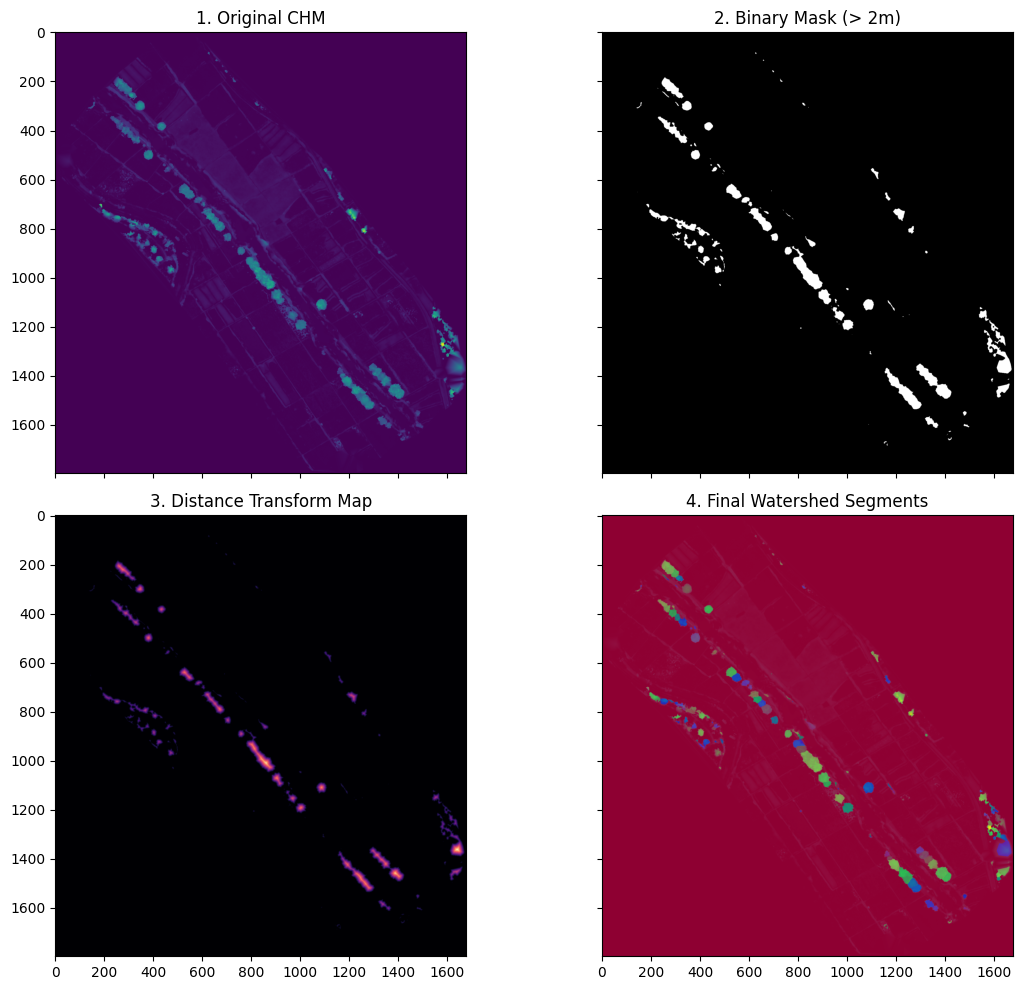

In [373]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(chm, cmap='viridis')
ax[0].set_title("1. Original CHM")

ax[1].imshow(watershed_mask, cmap='gray')
ax[1].set_title(f"2. Binary Mask (> {min_height_threshold}m)")

ax[2].imshow(distance_map, cmap='magma')
ax[2].set_title("3. Distance Transform Map")

# Overlay watershed boundaries on the CHM for the final check
ax[3].imshow(chm, cmap='viridis')
ax[3].imshow(labels, cmap='prism', alpha=0.4) # Random colors per clump
ax[3].set_title("4. Final Watershed Segments")

plt.tight_layout()
# plt.savefig(f'{inter_dir}/distance_transform_segmentation.png')
plt.show()

### Part Two:
### Bamboo Parameters

In [264]:
bamboo_polygons_path = f'{inter_dir}/bamboo_segments.gpkg'
normalized_las_path = f'{inter_dir}/normalized_las.las'
assert os.path.exists(bamboo_polygons_path) and os.path.exists(normalized_las_path), 'Doublecheck data sources.'

### ----------------------------------------------------
### Step 1: Reading in point cloud and bamboo boundaries
### ----------------------------------------------------

In [265]:
las = laspy.read(normalized_las_path)

gdf = gpd.read_file(bamboo_polygons_path)

In [240]:
points = np.vstack((las.x, las.y, las.z)).T

In [22]:
#creating 2D points for fast boundary checking
points_2d = [Point(x, y) for x, y in zip(las.x, las.y)]

### ------------------------------------------------------------------
### Step 2: Looping through every bamboo polygon
### ------------------------------------------------------------------
### ------------------------------------------------------------------
### Step 3: Calculate canopy volume
### ------------------------------------------------------------------
### ------------------------------------------------------------------
### Step 4: Calculate gap fraction
### ------------------------------------------------------------------
### ------------------------------------------------------------------
### Step 5: Export to CSV
### ------------------------------------------------------------------

In [ ]:
results = []

geometry_records = []

MIN_HOLLOW_CELLS = 4

for idx, row in gdf.iterrows():

    polygon = row['geometry']


    # ========================================================
    # FIND ALL LIDAR POINTS SITTING INSIDE BAMBOO BOUNDARY
    # ========================================================

    inside_mask = [polygon.contains(p) for p in points_2d]

    clipped_points = points[inside_mask]

    # skip to next polygon if no points are found in the polygon
    if len(clipped_points) < 4:
    
        print(f'Skipping plant {idx}: Not enough Lidar points.')
        continue

    # # create a tight 3D wrapper around the points to calculate volume
    #
    try:
    
        hull = ConvexHull(clipped_points)
        canopy_volume = hull.volume
    
    except Exception:
    
        # if points are too flat or perfectly aligned
        canopy_volume = 0.0


    # ========================================================
    # GAP FRACTION
    # ========================================================

    z_values = clipped_points[:, 2]
    
    ground_points_count = np.sum(z_values < 0.4)
    
    total_points_count = len(z_values)
    
    gap_fraction = ground_points_count / total_points_count


    # ========================================================
    # 1.3 m GEOMETRY
    # ========================================================

    
    try:

        (
        bh_geometry_feats,
        outer_geometry,
        hollow_geometry,
        smoothed_outer_geometry,
        ) = process_breast_height_geometry(
            breast_path=height_slice_stack_path,
            original_polygon=polygon,
            band_index=5,
        )

        # ====================================================
        # STORE GEOMETRIES FOR QGIS INSPECTION
        # ====================================================

        add_geometry_records(
            records=geometry_records,
            psp=row.get("psp", None),
            clump_id=idx,
            original_polygon=polygon,
            outer_geometry=outer_geometry,
            hollow_geometry=hollow_geometry,
            smoothed_outer_geometry=smoothed_outer_geometry,
        )


    except Exception as e:

        print(
            f"Warning: 1.3 m geometry failed for plant {idx}: {e}"
        )

        # ----------------------------------------------------
        # If processing fails, explicitly store failed values.
        # ----------------------------------------------------
        bh_geometry_feats = {

            "bh_n_positive_cells": 0,

            "bh_n_valid_cells": 0,

            "bh_outer_area_m2": np.nan,

            "bh_outer_perimeter_m": np.nan,

            "bh_outer_equivalent_diameter_m": np.nan,

            "bh_hollow_area_m2": np.nan,

            "bh_hollow_perimeter_m": np.nan,

            "bh_hollow_equivalent_diameter_m": np.nan,

            "bh_outside_area_m2": np.nan,

            "bh_slice_to_original_area_ratio": np.nan,
        }

        outer_geometry = None
        hollow_geometry = None
        smoothed_outer_geometry = None
    # ========================================================
    # STORE RESULTS
    # ========================================================
    results.append(

        {
            "plant_id": idx,

            "geometry": polygon,

            **bh_geometry_feats,
        }
    )


# ============================================================
# EXPORT TABULAR RESULTS
# ============================================================

df_results = pd.DataFrame(results)

df_results.to_csv(

    f"{inter_dir}/bamboo_params_breast_height.csv",

    index=False,
)

print(
    "Successfully saved metrics."
)


# ============================================================
# EXPORT OUTER + INNER 1.3 m GEOMETRIES FOR INSPECTION
# ============================================================

inspection_records = []

for record in geometry_records:

    if record["geometry_type"] in [

        "outer_slice",

        "hollow",

        "outside",

    ]:

        inspection_records.append(record)


if inspection_records:

    inspection_gdf = gpd.GeoDataFrame(

        inspection_records,

        geometry="geometry",

        crs=gdf.crs,
    )

    # --------------------------------------------------------
    # Remove empty geometries
    # --------------------------------------------------------

    inspection_gdf = inspection_gdf[

        inspection_gdf.geometry.notna()

        &

        ~inspection_gdf.geometry.is_empty

    ].copy()

    # --------------------------------------------------------
    # Export
    # --------------------------------------------------------

    inspection_gpkg = (

        f"{inter_dir}/bamboo_1p3m_geometry_inspection.gpkg"

    )

    inspection_gdf.to_file(

        inspection_gpkg,

        layer="bh_geometry",

        driver="GPKG",

    )

    print(

        f"Successfully exported geometry inspection file:\n"

        f"{inspection_gpkg}"

    )

else:

    print(

        "No 1.3 m geometries available for inspection."

    )

BH raster: valid=48768, positive=3614
BH points: 3614 raw
BH points after cleaning: 3409
BH outer geometry: area=14.6965, perimeter=16.1620
BH raster: valid=45942, positive=1924
BH points: 1924 raw
BH points after cleaning: 715
BH outer geometry: area=14.3649, perimeter=15.7947
BH raster: valid=45125, positive=4435
BH points: 4435 raw
BH points after cleaning: 2120
BH outer geometry: area=29.3512, perimeter=20.3127
BH raster: valid=43449, positive=3667
BH points: 3667 raw
BH points after cleaning: 2971
BH outer geometry: area=21.6301, perimeter=18.7550
BH raster: valid=42580, positive=5341
BH points: 5341 raw
BH points after cleaning: 3535
BH outer geometry: area=18.8370, perimeter=16.2660
BH raster: valid=42365, positive=3454
BH points: 3454 raw
BH points after cleaning: 1138
BH outer geometry: area=26.6911, perimeter=19.3243
BH raster: valid=41944, positive=2898
BH points: 2898 raw
BH points after cleaning: 1131
BH outer geometry: area=2.0178, perimeter=7.8580
BH raster: valid=37372,

In [267]:
bamboo_params_path = f'{inter_dir}/bamboo_params_breast_height.csv'
assert os.path.exists(bamboo_params_path), 'Check bamboo params path.'

##### CHM metrics

In [29]:
RENAME_MAP = {
    "max": "hmax",
    "mean": "hmean",
    "median": "hmedian",
    "min": "hmin",
    "std": "hstd",
}


def calculate_height_metrics(
    chm_path: str,
    bamboo_polygons_path: str,
    height_points_path: str,
):
    """
    Returns a GeoDataFrame of bamboo polygons with

        hmax      -> max CHM within .25 m of clinometer point
        hmean     -> mean CHM within polygon
        hmedian   -> median CHM within polygon
        hmin      -> minimum CHM within polygon
        hstd      -> std CHM within polygon

    Geometry in output is the bamboo polygon.
    """

    #############################################
    # Load data
    #############################################

    polygons = gpd.read_file(bamboo_polygons_path)
    points = gpd.read_file(height_points_path)

    with rasterio.open(chm_path) as src:
        raster_crs = src.crs

    polygons = polygons.to_crs(raster_crs)
    points = points.to_crs(raster_crs)

    #############################################
    # Match every point to its bamboo polygon
    #############################################

    points = gpd.sjoin(
        points,
        polygons,
        how="inner",
        predicate="within",
    )

    #############################################
    # Polygon statistics
    #############################################

    poly_stats = zonal_stats(
        polygons.geometry,
        chm_path,
        stats=["mean", "median", "min", "std"],
        nodata=-9999,
    )

    poly_stats = pd.DataFrame(poly_stats).rename(
        columns={
            "mean": "hmean",
            "median": "hmedian",
            "min": "hmin",
            "std": "hstd",
        }
    )

    polygons = pd.concat(
        [polygons.reset_index(drop=True), poly_stats],
        axis=1,
    )

    #############################################
    # HMAX from 1 m point buffer
    #############################################

    buffers = points.copy()
    buffers["geometry"] = buffers.buffer(0.25)

    max_stats = zonal_stats(
        buffers.geometry,
        chm_path,
        stats=["max"],
        nodata=-9999,
    )

    buffers["hmax"] = [s["max"] for s in max_stats]

    #############################################
    # Attach hmax to polygon
    #############################################

    # index_right came from spatial join and refers to polygon index
    hmax = (
        buffers.groupby("index_right")["hmax"]
        .max()
        .rename("hmax")
    )

    polygons["hmax"] = polygons.index.map(hmax)

    #############################################
    # Fill missing values
    #############################################

    metric_cols = [
        "hmax",
        "hmean",
        "hmedian",
        "hmin",
        "hstd",
    ]

    polygons[metric_cols] = polygons[metric_cols].fillna(0)

    return polygons

In [30]:
df_height_params = calculate_height_metrics(
    chm_path,
    bamboo_polygons_path,
    height_measurement_centers,
)

In [31]:
df_height_params.columns

Index(['clump_id', 'geometry', 'hmin', 'hmean', 'hstd', 'hmedian', 'hmax'], dtype='str')

In [32]:
df_height_params['geometry'].head()

0    POLYGON ((804450.594 9761254.908, 804450.515 9...
1    POLYGON ((804450.283 9761226.464, 804450.286 9...
2    POLYGON ((804451.194 9761246.679, 804451.123 9...
3    POLYGON ((804452.6 9761233.643, 804452.604 976...
4    POLYGON ((804452.197 9761237.197, 804452.198 9...
Name: geometry, dtype: geometry

In [33]:
len(df_height_params)

13

#### Merge the params to height params

In [268]:
df_lidar_params = pd.read_csv(bamboo_params_path)

In [269]:
df_lidar_params["geometry"] = df_lidar_params["geometry"].apply(wkt.loads)

# 3. Instantiate the GeoDataFrame with the CRS
gdf_lidar_params = gpd.GeoDataFrame(
    df_lidar_params, geometry="geometry", crs=32735
)

In [270]:
gdf_lidar_params.head()

,plant_id,geometry,bh_n_positive_cells,bh_n_valid_cells,bh_n_points_used_for_boundary,bh_cleaning_eps,bh_outer_area_m2,bh_outer_perimeter_m,bh_outer_equivalent_diameter_m,bh_hollow_area_m2,bh_hollow_perimeter_m,bh_hollow_equivalent_diameter_m,bh_outside_area_m2,bh_n_points_removed_as_noise,bh_geometry_status,bh_solid_fraction
0,0,"POLYGON ((799095.654 9763210.4, 799095.531 976...",3614,48768,3409,0.084853,14.696550,16.162015,4.325763,0.04770,2.139026,0.246442,29.206305,205,success,NaN
1,1,"POLYGON ((799039.2 9763206.42, 799039.2 976320...",1924,45942,715,0.090000,14.364900,15.794663,4.276676,0.00135,0.162426,0.041459,27.015746,1209,success,NaN
2,2,"POLYGON ((799073.057 9763208.584, 799073.063 9...",4435,45125,2120,0.090000,29.351157,20.312688,6.113187,0.01350,0.764120,0.131106,11.268448,2315,success,NaN
3,3,"POLYGON ((799065.171 9763207.65, 799065.136 97...",3667,43449,2971,0.094868,21.630150,18.755035,5.247891,0.00585,0.589427,0.086304,17.450892,696,success,NaN
4,4,"POLYGON ((799084.609 9763214.226, 799084.622 9...",5341,42580,3535,0.067082,18.837000,16.265950,4.897348,0.04725,2.518475,0.245277,19.484516,1806,success,NaN


In [271]:
names = {'bh_n_positive_cells' : 'breast_height_points', 'bh_n_valid_cells' : 'breast_height_valid_points',
    'bh_n_points_used_for_boundary' : 'breast_height_filtered_points', 'bh_cleaning_eps' : 'breast_height_cleaning_distance', 'bh_outer_area_m2' : 'breast_height_area',
    'bh_outer_perimeter_m' : 'breast_height_perimeter_m', 'bh_outer_equivalent_diameter_m' : 'breast_height_diameter'}
gdf_lidar_params.rename(columns=names, inplace=True)

In [272]:
gdf_lidar_params = gdf_lidar_params[['breast_height_points',
       'breast_height_valid_points', 'breast_height_filtered_points',
       'breast_height_cleaning_distance', 'breast_height_area',
       'breast_height_perimeter_m', 'breast_height_diameter', 'bh_outside_area_m2',  'geometry']]

In [89]:
len(df_height_params) == len(gdf_lidar_params)

NameError: name 'df_height_params' is not defined

In [90]:
matches_mask = df_height_params['geometry'].geom_equals(gdf_lidar_params['geometry'])
match_count = matches_mask.sum()

NameError: name 'df_height_params' is not defined

In [25]:
match_count ==len(df_height_params) == len(gdf_lidar_params)

True

In [26]:
bamboo_params_df = df_height_params.merge(gdf_lidar_params, on='geometry', how='inner')

In [27]:
bamboo_params_df['canopy_area'] = bamboo_params_df.geometry.area

In [28]:
bamboo_params_df.drop(columns=['clump_id', 'plant_id'], inplace=True)

In [29]:
bamboo_params_df.head()

,geometry,hmin,hmean,hstd,hmedian,hmax,total_points,canopy_volume_m3,gap_fraction,bh_openness_integral,...,bh_inflection_u,bh_inflection_curvature,bh_arc_length,bh_beer_lambert_A,bh_beer_lambert_k,bh_n_cells,vertical_density_integral,vertical_k_integral,n_valid_height_slices,canopy_area
0,"POLYGON ((799095.654 9763210.4, 799095.531 976...",2.559,5.479582,1.269237,5.5000,5.877,306844,318.799853,0.067735,0.070750,...,0.989915,1.169948e+12,11.217711,58.917846,-2.408004,109781,251.730990,-0.610284,6,43.902855
1,"POLYGON ((799039.2 9763206.42, 799039.2 976320...",0.171,5.005358,1.423138,5.2560,6.078,324971,273.554964,0.073616,0.022864,...,0.949607,8.082068e-01,4.782072,2.957336,-5.471003,103464,207.141009,-3.237248,6,41.380646
2,"POLYGON ((799073.057 9763208.584, 799073.063 9...",2.208,4.497947,0.945491,4.4620,5.206,292135,223.507880,0.251452,NaN,...,0.989927,NaN,NaN,190.762920,0.209887,101560,239.413978,0.116749,6,40.619605
3,"POLYGON ((799065.171 9763207.65, 799065.136 97...",0.404,5.575242,1.000610,5.7215,5.524,437743,263.543331,0.251472,0.068890,...,0.989924,3.163489e+09,9.935709,45.723171,-2.575189,97706,312.243483,-3.196087,6,39.081042
4,"POLYGON ((799084.609 9763214.226, 799084.622 9...",0.315,4.839440,0.918863,4.9850,6.932,257823,253.110557,0.099281,0.087271,...,0.989911,6.570016e+10,10.905085,967.559414,5.714149,95797,206.873343,34.537803,6,38.321516


In [273]:
gdf_lidar_params.to_file(f'{inter_dir}/individual_bamboo_params_breast_height_v1.gpkg', index=False)